# Generic Employee EDA

Point `DATASET_PATH` at any employee dataset CSV and run the notebook top to bottom.

This notebook focuses on:
- dataset shape and preview
- inferred feature types
- missingness and uniqueness
- low/high cardinality flags
- likely ID / date / text-like columns
- numeric and categorical distributions


In [74]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)

# Update this path for the dataset you want to inspect.
DATASET_PATH = "../data/Absenteeism_at_work.csv"


In [75]:
def resolve_dataset_path(dataset_path: str) -> Path:
    raw_path = Path(dataset_path)
    if raw_path.exists():
        return raw_path.resolve()

    cwd = Path.cwd().resolve()
    candidate_dirs = [cwd]
    if cwd.name == "scripts":
        candidate_dirs.append(cwd.parent)
    elif (cwd / "scripts").exists():
        candidate_dirs.append((cwd / "scripts").resolve())

    for base_dir in candidate_dirs:
        candidate = (base_dir / dataset_path).resolve()
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find dataset: {dataset_path}")


def is_datetime_like(series: pd.Series) -> bool:
    if pd.api.types.is_datetime64_any_dtype(series):
        return True
    if not (pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)):
        return False

    sample = series.dropna().astype(str).head(200)
    if sample.empty:
        return False

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        parsed_default = pd.to_datetime(sample, errors="coerce")
        parsed_dayfirst = pd.to_datetime(sample, errors="coerce", dayfirst=True)
    parse_rate = max(parsed_default.notna().mean(), parsed_dayfirst.notna().mean())
    return parse_rate >= 0.8


def is_boolean_like(series: pd.Series) -> bool:
    values = {str(v).strip().lower() for v in series.dropna().unique()}
    if not values:
        return False
    boolean_tokens = {"0", "1", "true", "false", "yes", "no", "y", "n"}
    return values.issubset(boolean_tokens) or len(values) == 2


def cardinality_bucket(unique_count: int) -> str:
    if unique_count <= 1:
        return "constant"
    if unique_count <= 10:
        return "low"
    if unique_count <= 30:
        return "medium"
    if unique_count <= 100:
        return "high"
    return "very high"


def infer_feature_type(series: pd.Series) -> str:
    name = series.name.lower()
    non_null = series.dropna()
    unique_count = non_null.nunique()
    unique_ratio = unique_count / len(non_null) if len(non_null) else 0

    if non_null.empty:
        return "empty"
    if unique_count <= 1:
        return "constant"
    if is_datetime_like(series):
        return "datetime"
    if is_boolean_like(series):
        return "binary"
    if any(token in name for token in ["id", "email", "number", "code"]) and unique_ratio > 0.8:
        return "identifier"

    if pd.api.types.is_numeric_dtype(series):
        if pd.api.types.is_integer_dtype(series) and unique_count <= 20:
            return "numeric_discrete"
        return "numeric_continuous"

    as_text = non_null.astype(str)
    avg_length = as_text.str.len().mean()
    avg_words = as_text.str.split().str.len().mean()
    if avg_length > 25 or avg_words > 3:
        return "text_like"

    bucket = cardinality_bucket(unique_count)
    return f"categorical_{bucket.replace(' ', '_')}"


def sample_values(series: pd.Series, limit: int = 5) -> str:
    values = series.dropna().astype(str).unique()[:limit]
    return ", ".join(values)


def build_feature_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for column in df.columns:
        series = df[column]
        non_null = series.dropna()
        unique_count = non_null.nunique()
        missing_count = int(series.isna().sum())
        missing_pct = round((missing_count / len(df)) * 100, 2) if len(df) else 0
        unique_pct = round((unique_count / len(non_null)) * 100, 2) if len(non_null) else 0
        inferred_type = infer_feature_type(series)
        notes = []

        if unique_count <= 1:
            notes.append("constant")
        if unique_pct >= 95 and len(non_null) > 20:
            notes.append("near-unique")
        if missing_pct >= 30:
            notes.append("high-missingness")
        if cardinality_bucket(unique_count) in {"high", "very high"}:
            notes.append("high-cardinality")

        row = {
            "column": column,
            "dtype": str(series.dtype),
            "inferred_type": inferred_type,
            "rows": len(series),
            "non_null": int(non_null.shape[0]),
            "missing_count": missing_count,
            "missing_pct": missing_pct,
            "unique_count": int(unique_count),
            "unique_pct_non_null": unique_pct,
            "cardinality": cardinality_bucket(unique_count),
            "sample_values": sample_values(series),
            "notes": ", ".join(notes),
        }

        if pd.api.types.is_numeric_dtype(series):
            row["min"] = non_null.min() if not non_null.empty else None
            row["median"] = non_null.median() if not non_null.empty else None
            row["max"] = non_null.max() if not non_null.empty else None
            row["std"] = round(float(non_null.std()), 3) if len(non_null) > 1 else 0.0
        else:
            row["min"] = None
            row["median"] = None
            row["max"] = None
            row["std"] = None

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        by=["inferred_type", "missing_pct", "unique_count"],
        ascending=[True, False, False],
    ).reset_index(drop=True)


In [76]:
dataset_file = resolve_dataset_path(DATASET_PATH)
df = pd.read_csv(dataset_file)
profile = build_feature_profile(df)

plots_dir = Path("eda_reports")
plots_dir.mkdir(exist_ok=True)
plots_pdf_path = plots_dir / f"{dataset_file.stem}_eda_plots.pdf"

try:
    pdf.close()
except Exception:
    pass

pdf = PdfPages(plots_pdf_path)

print(f"Dataset: {dataset_file}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Plots PDF: {plots_pdf_path}")

display(df.head())


Dataset: /Users/sarakhan/Projects/Uni/Gen-Trees/data/Absenteeism_at_work.csv
Shape: 740 rows x 21 columns
Duplicate rows: 34
Plots PDF: eda_reports/Absenteeism_at_work_eda_plots.pdf


,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,Hit target,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,reason_26,month_7,day_3,season_1,289,36,13,33,239.554,97,0,education_1,son_2,1,0,pet_1,90,172,30,4
1,36,reason_0,month_7,day_3,season_1,118,13,18,50,239.554,97,1,education_1,son_1,1,0,pet_0,98,178,31,0
2,3,reason_23,month_7,day_4,season_1,179,51,18,38,239.554,97,0,education_1,son_0,1,0,pet_0,89,170,31,2
3,7,reason_7,month_7,day_5,season_1,279,5,14,39,239.554,97,0,education_1,son_2,1,1,pet_0,68,168,24,4
4,11,reason_23,month_7,day_5,season_1,289,36,13,33,239.554,97,0,education_1,son_2,1,0,pet_1,90,172,30,2


In [77]:
type_counts = profile["inferred_type"].value_counts().rename_axis("inferred_type").reset_index(name="column_count")

print("Inferred feature types")
display(type_counts)

print("Column profile")
display(profile)

high_cardinality = profile.loc[profile["cardinality"].isin(["high", "very high"]), ["column", "inferred_type", "unique_count", "notes"]]
likely_identifiers = profile.loc[profile["inferred_type"] == "identifier", ["column", "unique_count", "unique_pct_non_null", "sample_values"]]
likely_dates = profile.loc[profile["inferred_type"] == "datetime", ["column", "sample_values"]]
constant_columns = profile.loc[profile["cardinality"] == "constant", ["column", "sample_values"]]

print("High-cardinality columns")
display(high_cardinality if not high_cardinality.empty else pd.DataFrame({"message": ["None detected"]}))

print("Likely identifier columns")
display(likely_identifiers if not likely_identifiers.empty else pd.DataFrame({"message": ["None detected"]}))

print("Likely datetime columns")
display(likely_dates if not likely_dates.empty else pd.DataFrame({"message": ["None detected"]}))

print("Constant columns")
display(constant_columns if not constant_columns.empty else pd.DataFrame({"message": ["None detected"]}))


Inferred feature types


,inferred_type,column_count
0,numeric_continuous,6
1,categorical_low,5
2,numeric_discrete,5
3,binary,3
4,categorical_medium,2


Column profile


,column,dtype,inferred_type,rows,non_null,missing_count,missing_pct,unique_count,unique_pct_non_null,cardinality,sample_values,notes,min,median,max,std
0,Disciplinary failure,int64,binary,740,740,0,0.0,2,0.27,low,"0, 1",,0.000,0.000,1.000,0.226
1,Social drinker,int64,binary,740,740,0,0.0,2,0.27,low,"1, 0",,0.000,1.000,1.000,0.496
2,Social smoker,int64,binary,740,740,0,0.0,2,0.27,low,"0, 1",,0.000,0.000,1.000,0.260
3,Pet,object,categorical_low,740,740,0,0.0,6,0.81,low,"pet_1, pet_0, pet_4, pet_2, pet_5",,NaN,NaN,NaN,NaN
4,Day of the week,object,categorical_low,740,740,0,0.0,5,0.68,low,"day_3, day_4, day_5, day_6, day_2",,NaN,NaN,NaN,NaN
5,Son,object,categorical_low,740,740,0,0.0,5,0.68,low,"son_2, son_1, son_0, son_4, son_3",,NaN,NaN,NaN,NaN
6,Seasons,object,categorical_low,740,740,0,0.0,4,0.54,low,"season_1, season_4, season_2, season_3",,NaN,NaN,NaN,NaN
7,Education,object,categorical_low,740,740,0,0.0,4,0.54,low,"education_1, education_3, education_2, education_4",,NaN,NaN,NaN,NaN
8,Reason for absence,object,categorical_medium,740,740,0,0.0,28,3.78,medium,"reason_26, reason_0, reason_23, reason_7, reason_22",,NaN,NaN,NaN,NaN
9,Month of absence,object,categorical_medium,740,740,0,0.0,13,1.76,medium,"month_7, month_8, month_9, month_10, month_11",,NaN,NaN,NaN,NaN


High-cardinality columns


...

,message
0,None detected


Likely datetime columns


,message
0,None detected


Constant columns


,message
0,None detected


In [78]:
missing = profile.loc[profile["missing_count"] > 0, ["column", "missing_pct"]].sort_values("missing_pct", ascending=False)

if missing.empty:
    print("No missing values detected.")
else:
    plt.figure(figsize=(10, max(4, len(missing) * 0.35)))
    sns.barplot(data=missing, x="missing_pct", y="column", color="#4d908e")
    plt.title("Missingness by Column")
    plt.xlabel("Missing %")
    plt.ylabel("")
    plt.tight_layout()
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()
    plt.close()

numeric_cols = profile.loc[
    profile["inferred_type"].isin(["numeric_continuous", "numeric_discrete"]),
    "column",
].tolist()
binary_cols = profile.loc[profile["inferred_type"] == "binary", "column"].tolist()
constant_cols = profile.loc[profile["inferred_type"] == "constant", "column"].tolist()
categorical_cols = profile.loc[profile["inferred_type"].str.startswith("categorical_"), "column"].tolist()
text_like_cols = profile.loc[profile["inferred_type"] == "text_like", "column"].tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Binary columns ({len(binary_cols)}): {binary_cols}")
print(f"Constant columns ({len(constant_cols)}): {constant_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Text-like columns ({len(text_like_cols)}): {text_like_cols}")


No missing values detected.
Numeric columns (11): ['Work load Average/day ', 'ID', 'Weight', 'Distance from Residence to Work', 'Transportation expense', 'Age', 'Absenteeism time in hours', 'Service time', 'Body mass index', 'Height', 'Hit target']
Binary columns (3): ['Disciplinary failure', 'Social drinker', 'Social smoker']
Constant columns (0): []
Categorical columns (7): ['Pet', 'Day of the week', 'Son', 'Seasons', 'Education', 'Reason for absence', 'Month of absence']
Text-like columns (0): []


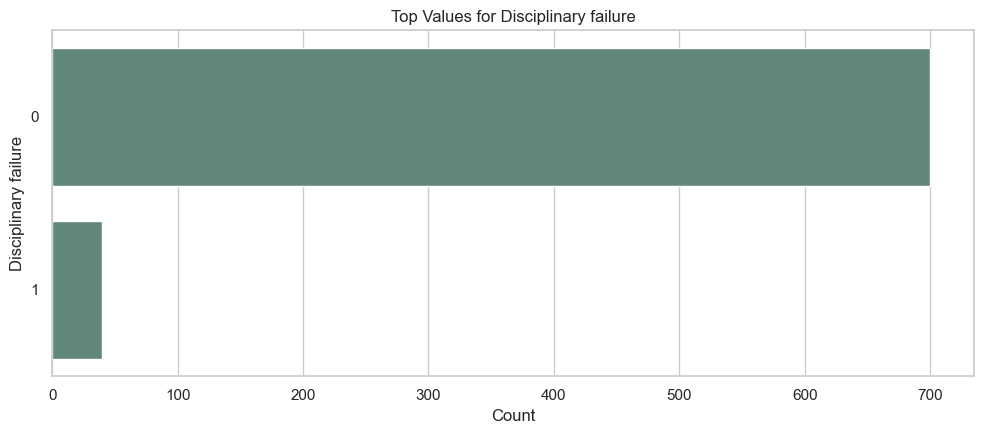

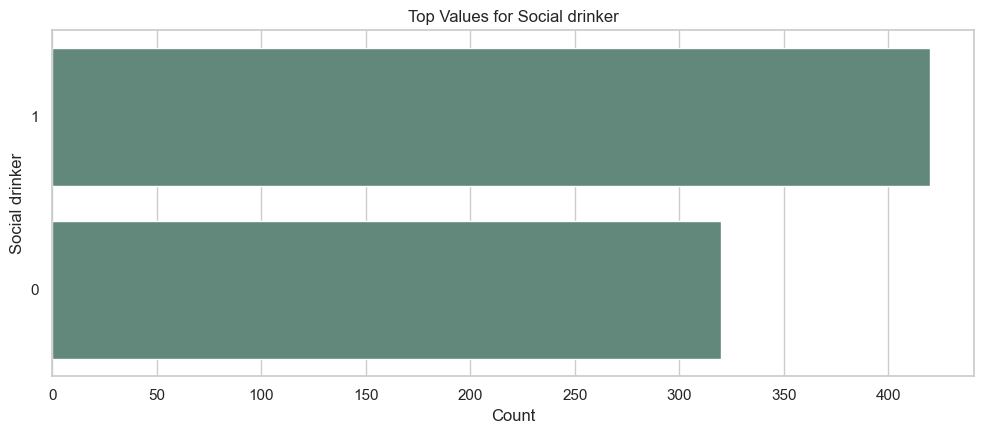

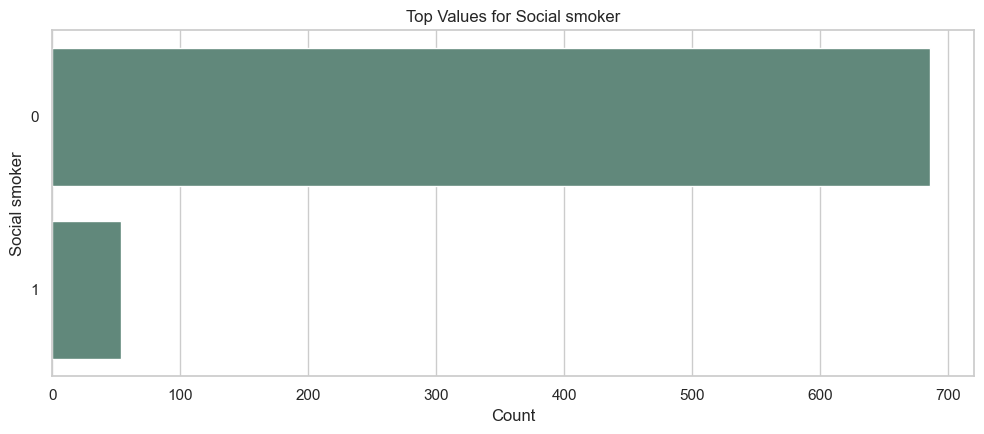

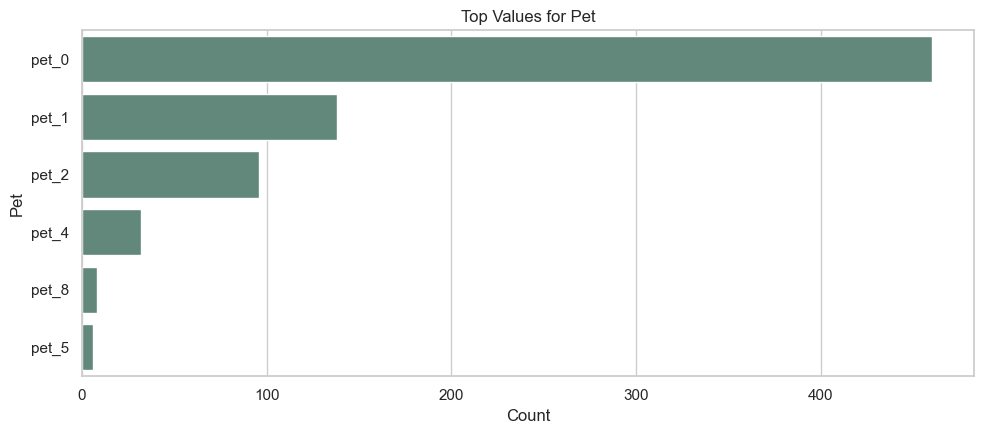

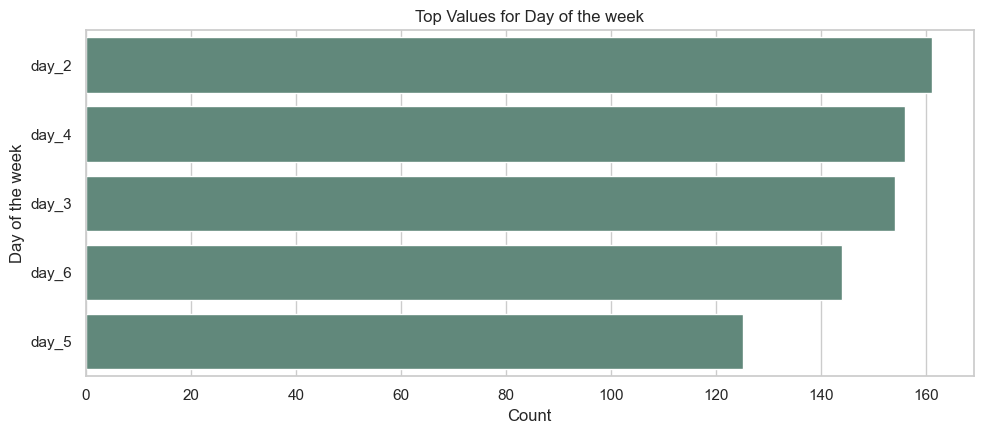

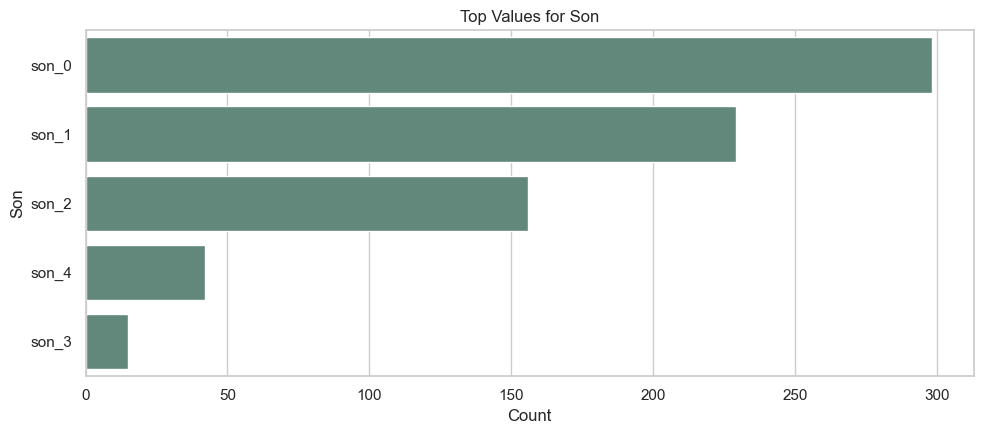

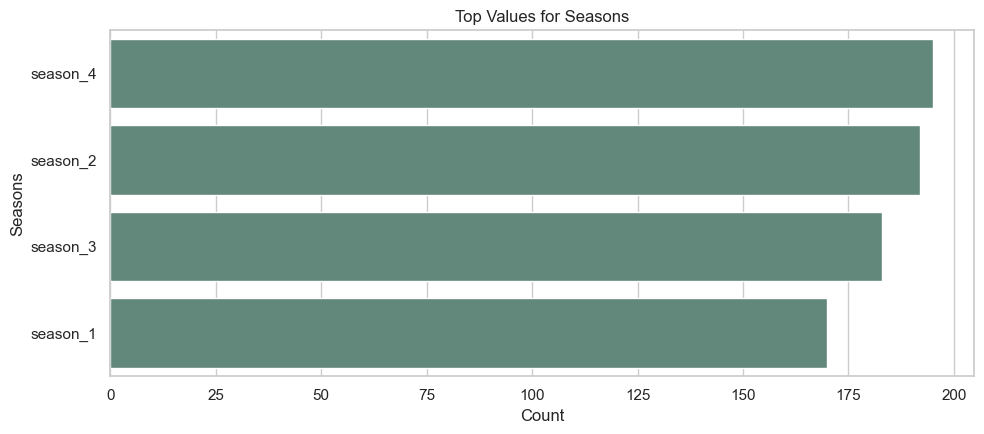

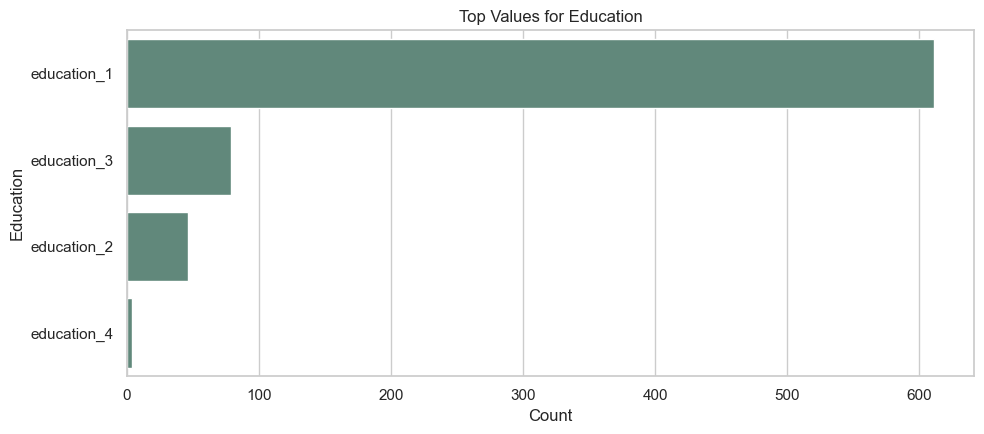

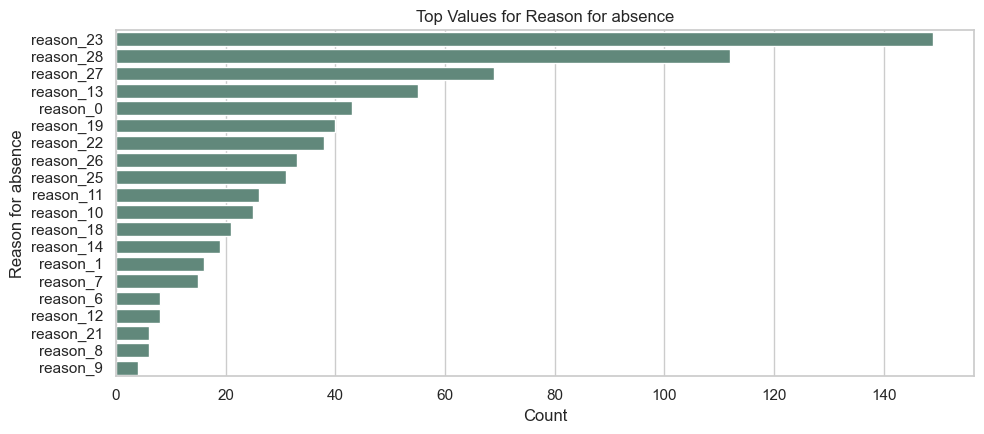

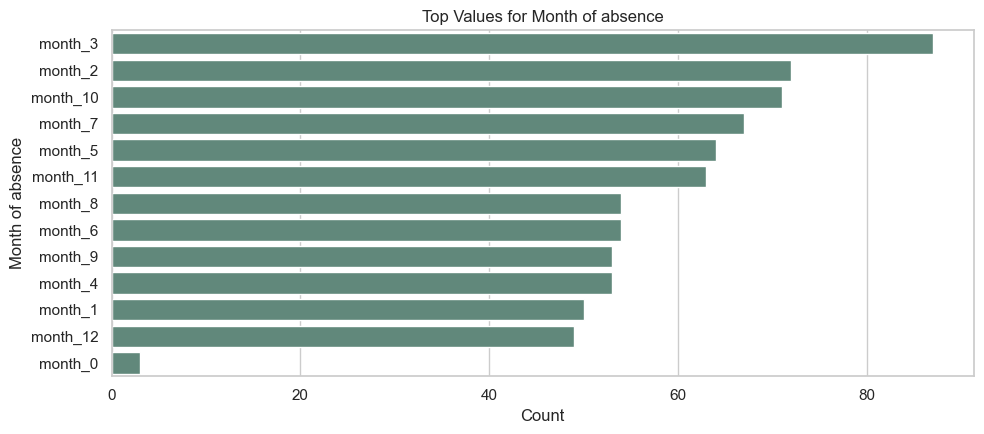

Categorical and binary plots generated above.


In [79]:
plot_categorical_like = profile.loc[
    profile["inferred_type"].isin(["binary"]) | profile["inferred_type"].str.startswith("categorical_"),
    "column",
].tolist()

for column in plot_categorical_like:
    series = df[column]
    non_null = series.dropna()

    if non_null.empty:
        print(f"Skipping {column}: all values are missing.")
        continue

    counts = non_null.astype(str).value_counts().head(20)
    plt.figure(figsize=(10, 4.5))
    sns.barplot(x=counts.values, y=counts.index, color="#5b8e7d")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.title(f"Top Values for {column}")
    plt.tight_layout()
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()
    plt.close()

print("Categorical and binary plots generated above.")


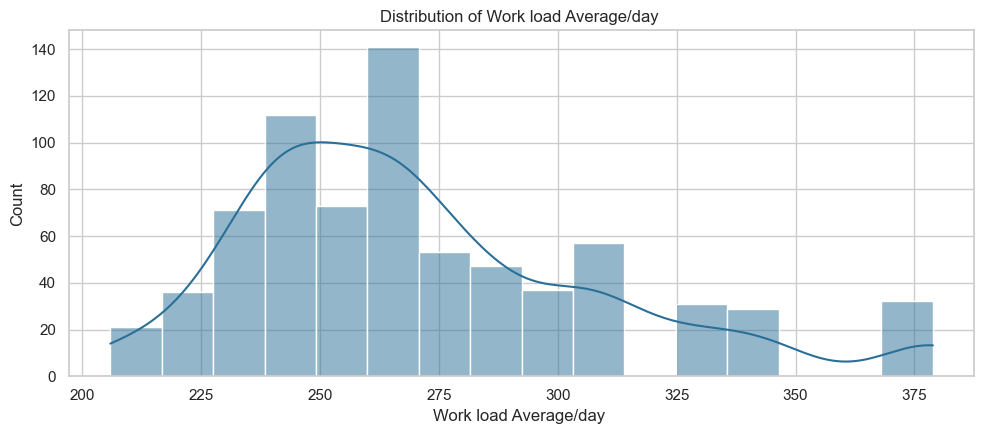

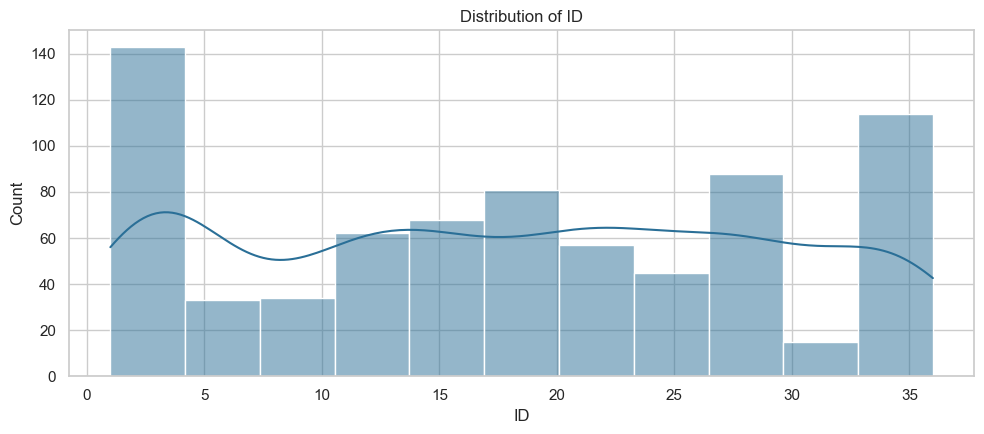

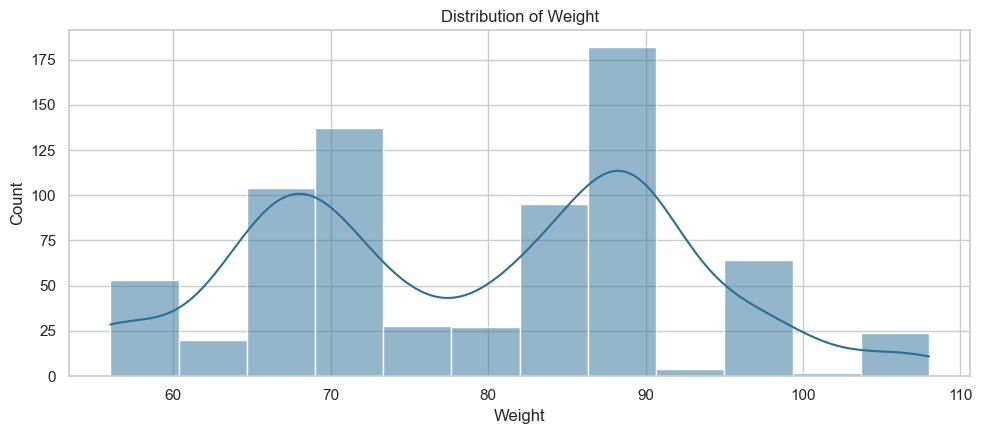

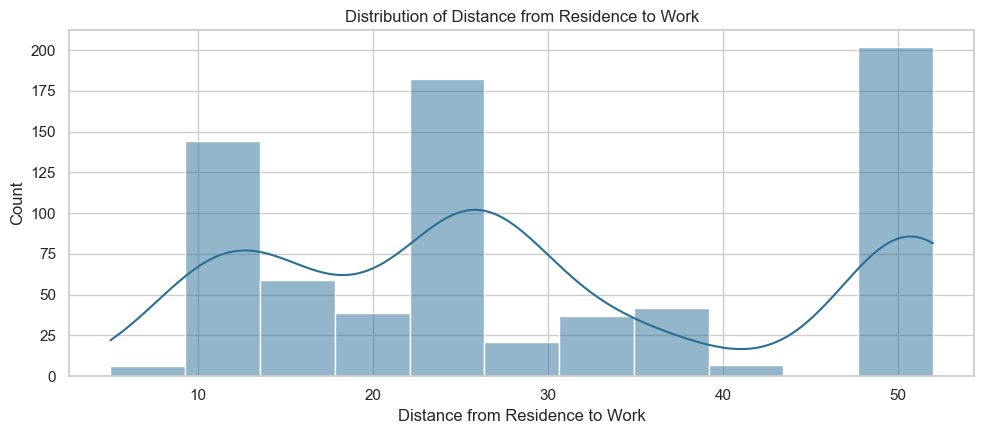

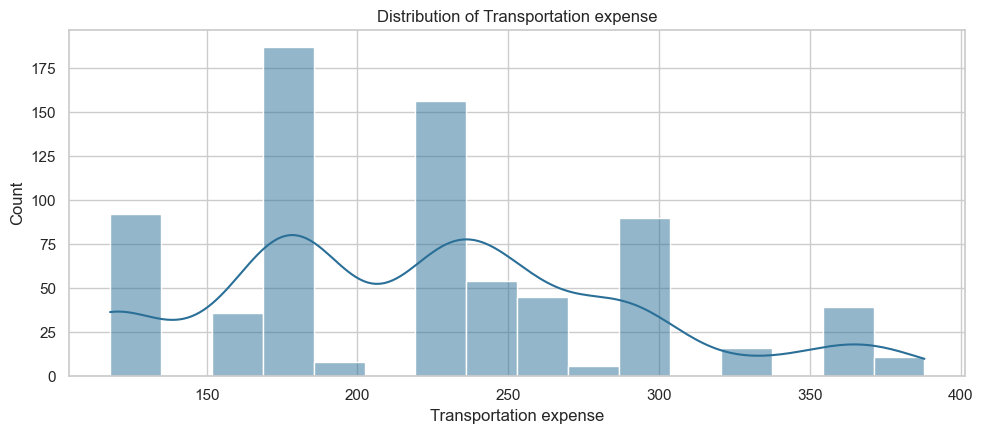

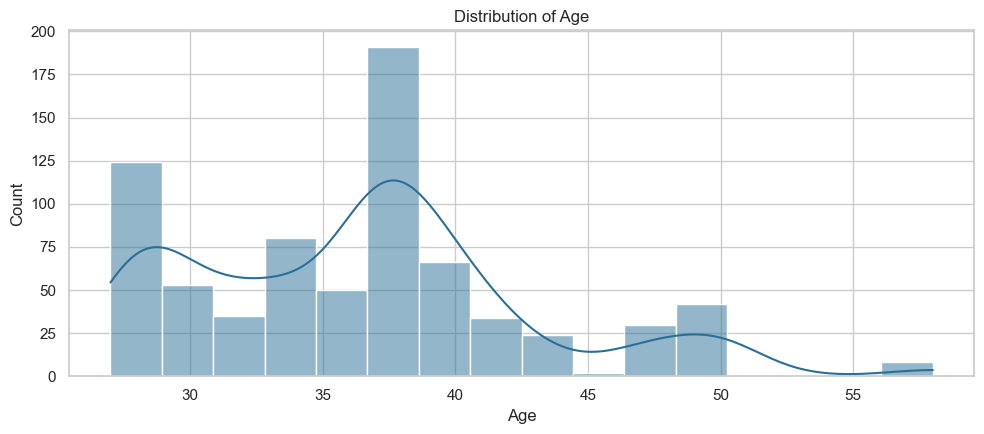

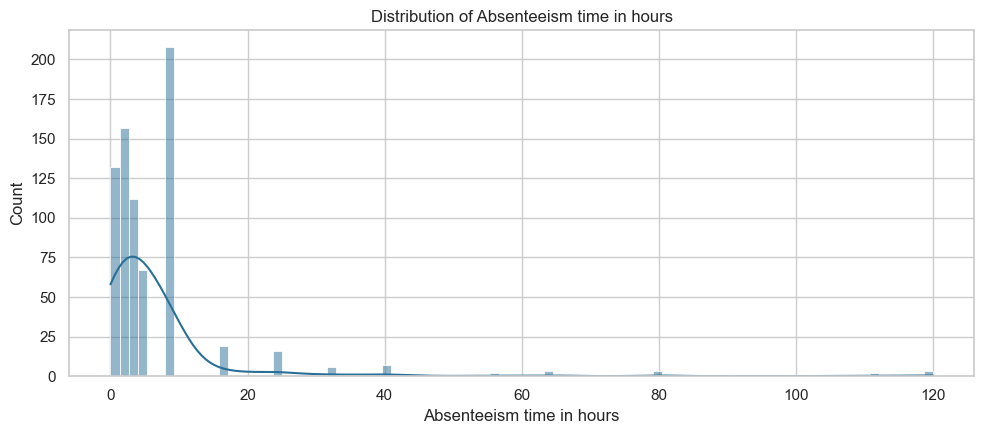

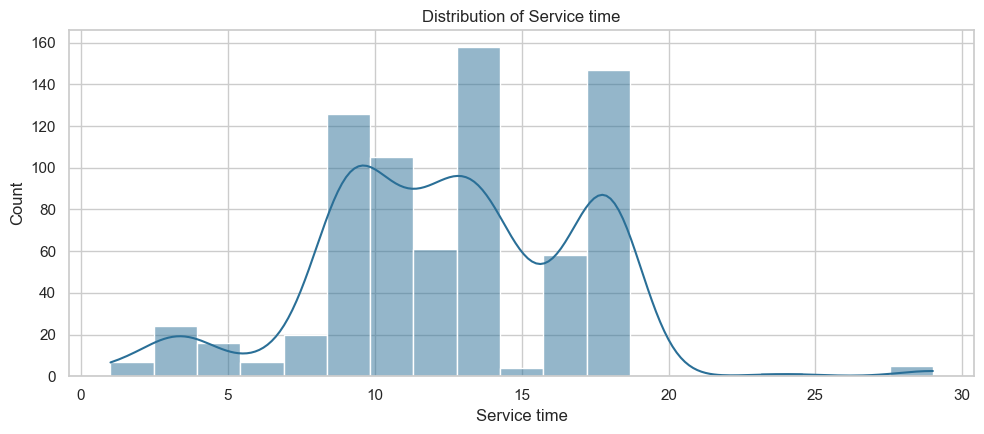

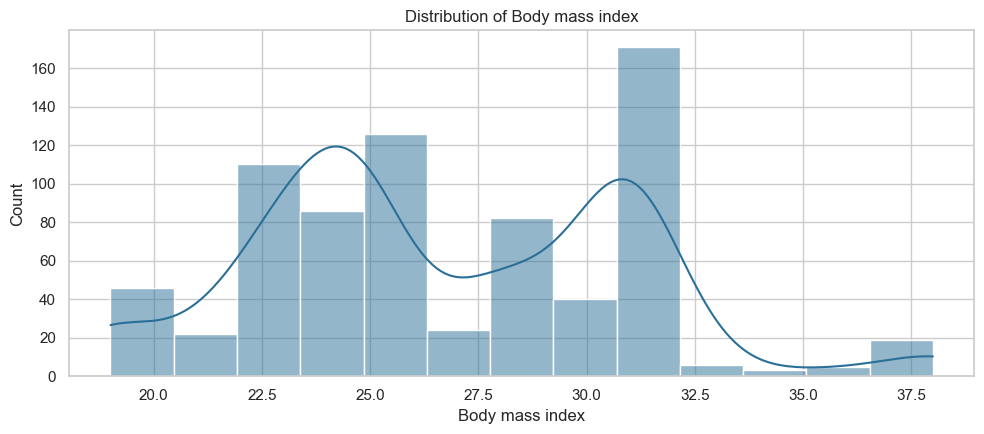

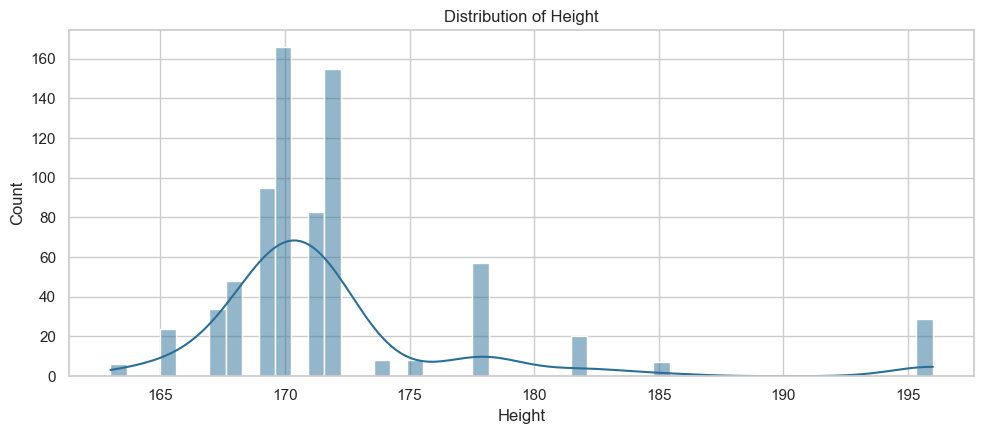

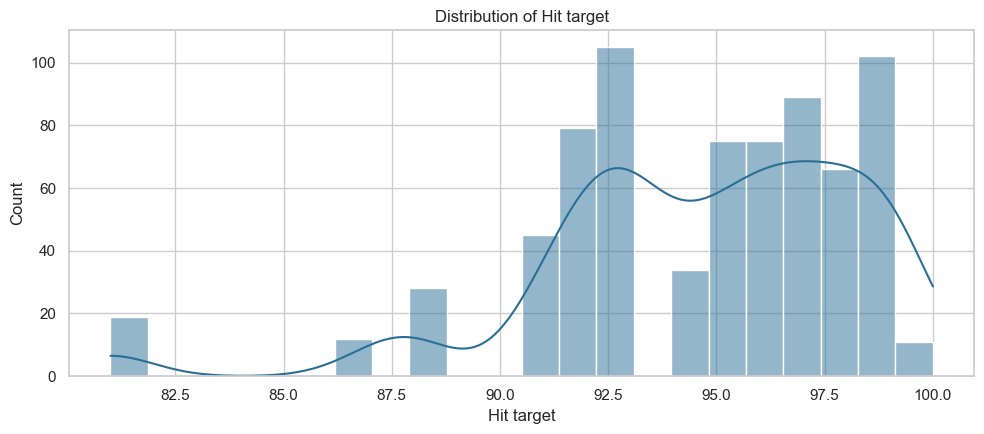

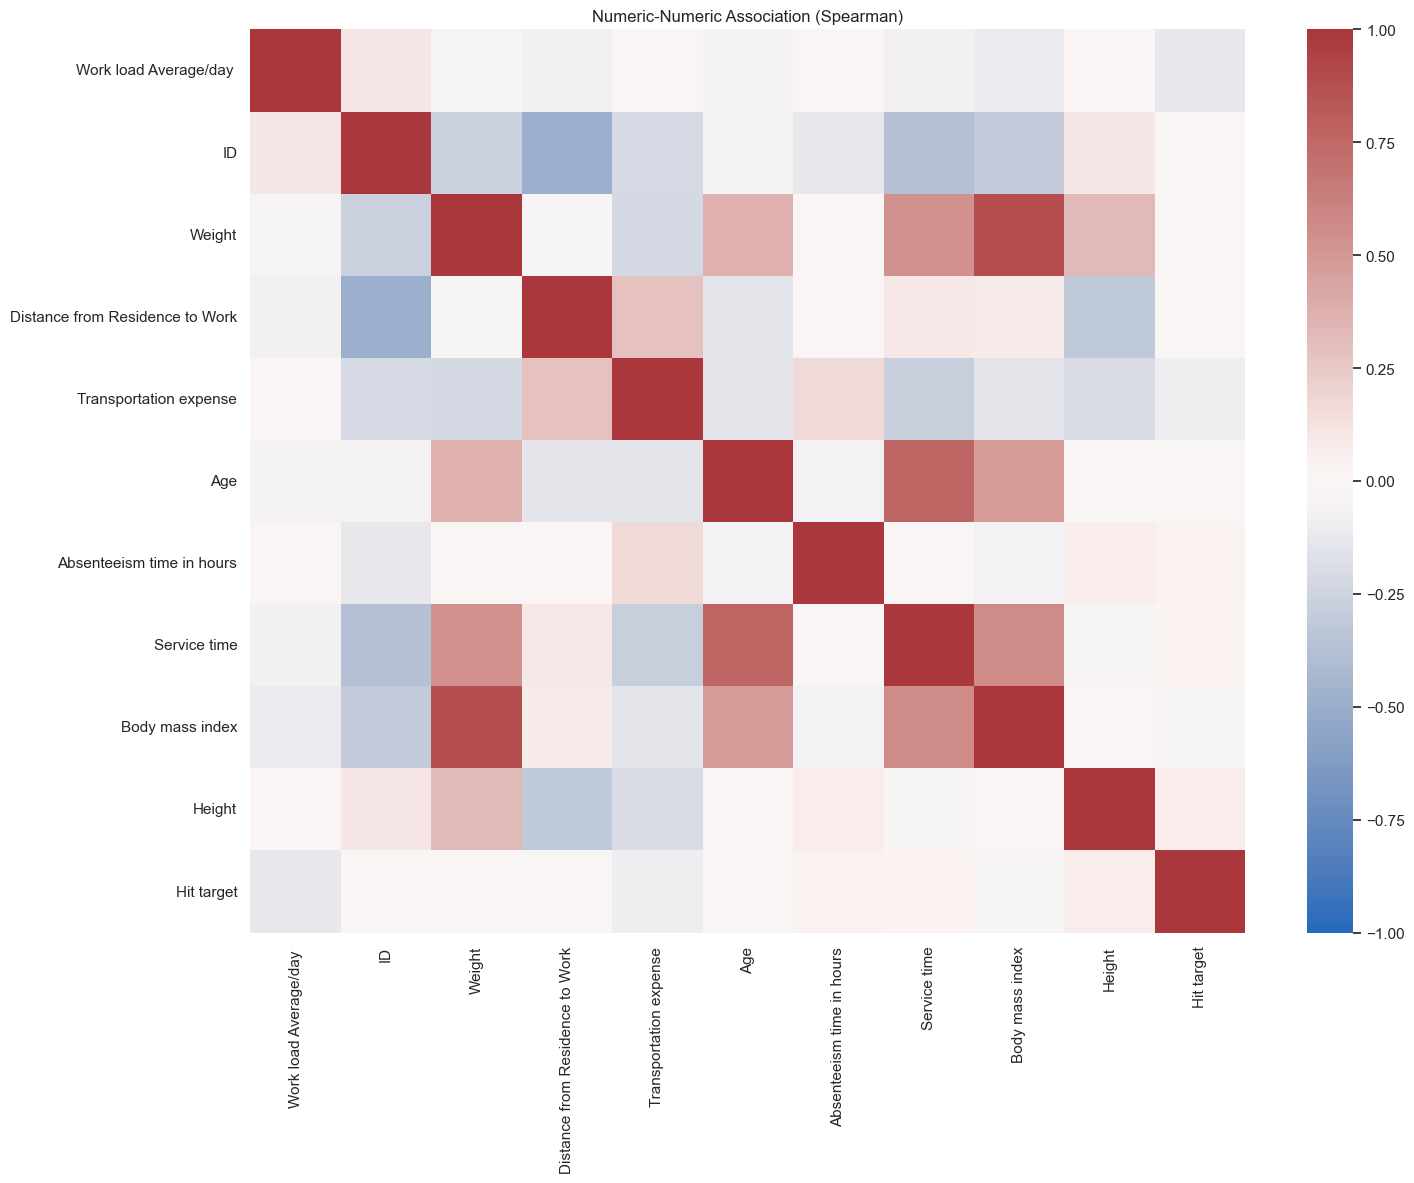

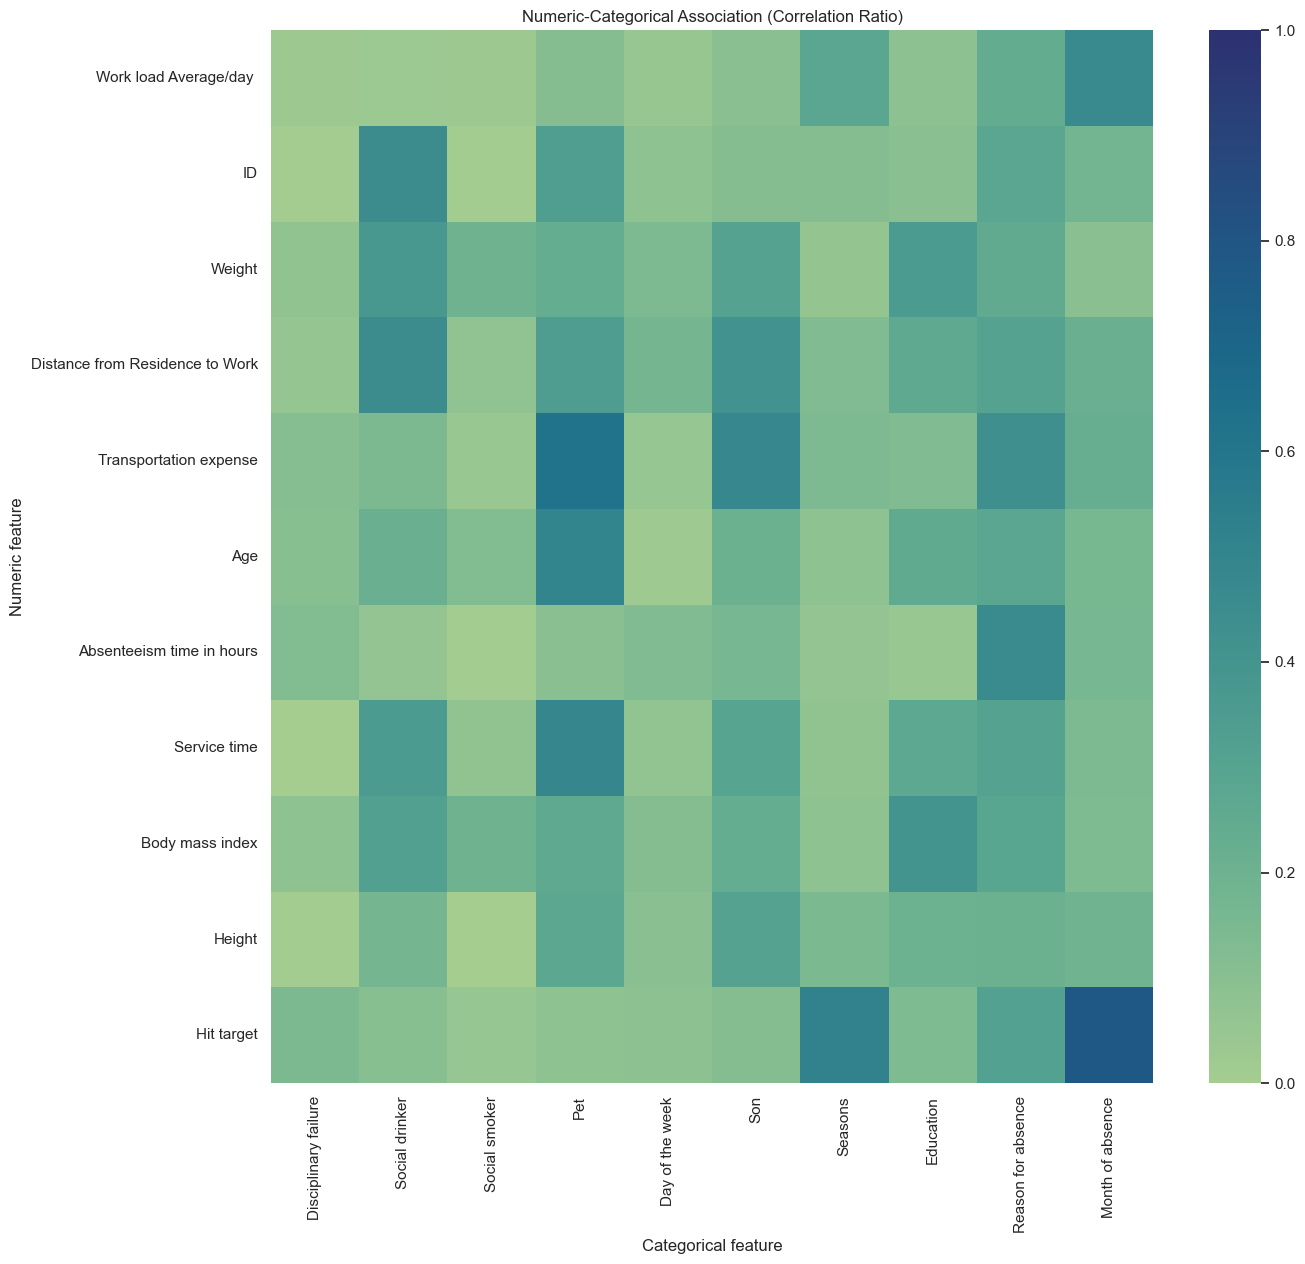

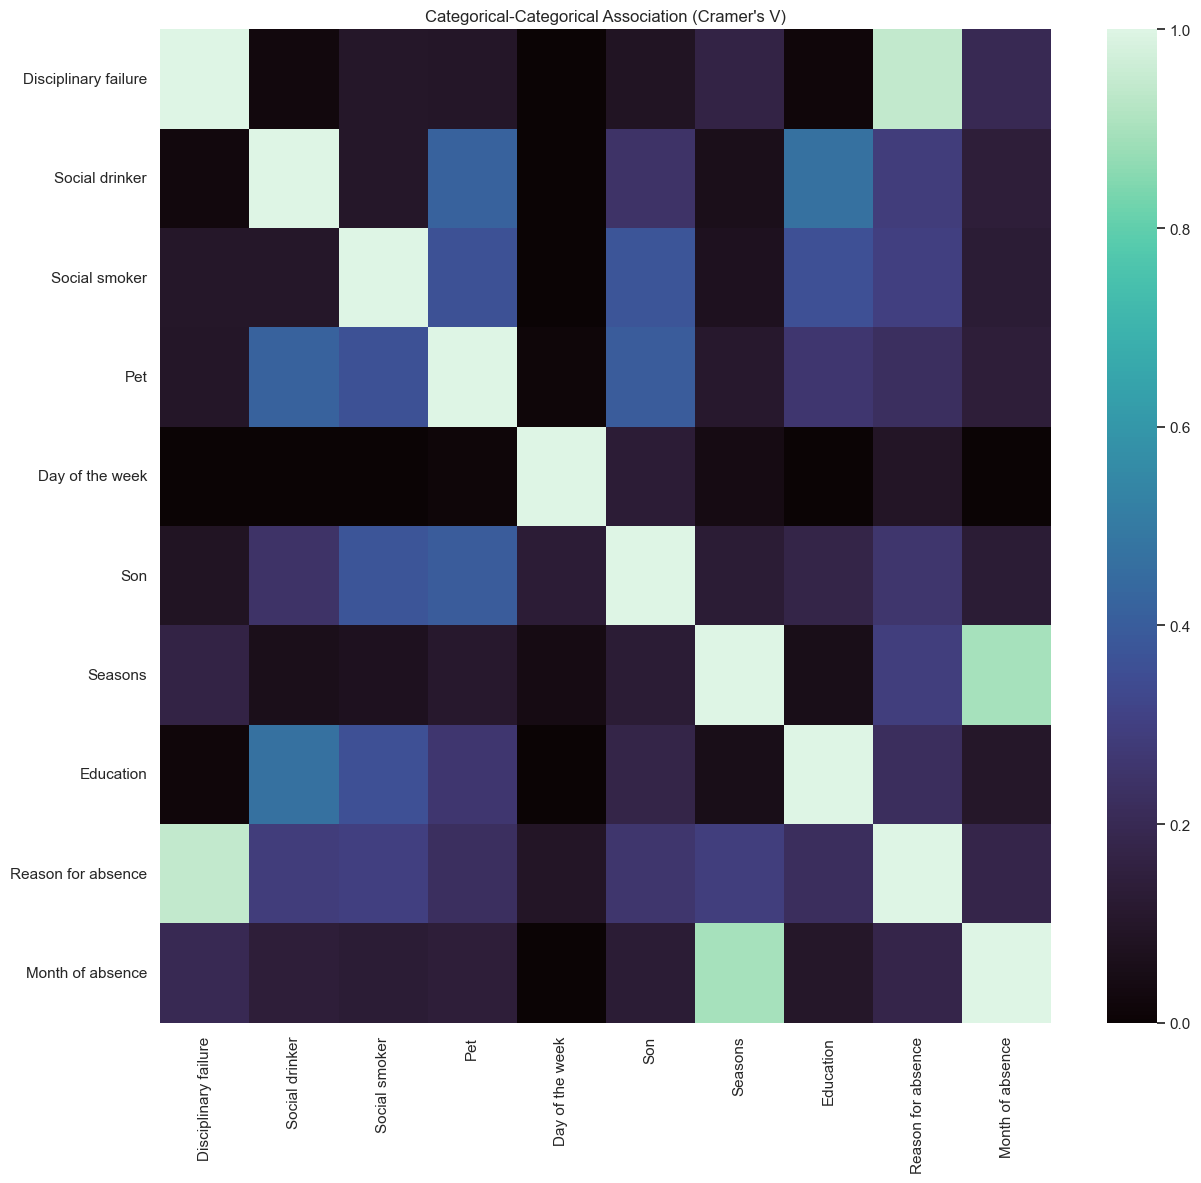

Feature association summary (closer to 1 means a stronger relationship)


,pair_type,feature_a,feature_b,association,direction,metric
0,categorical-categorical,Disciplinary failure,Reason for absence,0.943883,NaN,cramers_v
1,categorical-categorical,Seasons,Month of absence,0.895914,NaN,cramers_v
2,numeric-numeric,Weight,Body mass index,0.887294,0.887294,abs(spearman)
3,numeric-categorical,Hit target,Month of absence,0.781747,NaN,correlation_ratio
4,numeric-numeric,Age,Service time,0.759053,0.759053,abs(spearman)
...,...,...,...,...,...,...
205,categorical-categorical,Day of the week,Month of absence,0.000000,NaN,cramers_v
206,categorical-categorical,Social drinker,Day of the week,0.000000,NaN,cramers_v
207,categorical-categorical,Social smoker,Day of the week,0.000000,NaN,cramers_v
208,categorical-categorical,Disciplinary failure,Day of the week,0.000000,NaN,cramers_v


Top 20 strongest feature associations


,pair_type,feature_a,feature_b,association,direction,metric
0,categorical-categorical,Disciplinary failure,Reason for absence,0.943883,NaN,cramers_v
1,categorical-categorical,Seasons,Month of absence,0.895914,NaN,cramers_v
2,numeric-numeric,Weight,Body mass index,0.887294,0.887294,abs(spearman)
3,numeric-categorical,Hit target,Month of absence,0.781747,NaN,correlation_ratio
4,numeric-numeric,Age,Service time,0.759053,0.759053,abs(spearman)
5,numeric-categorical,Transportation expense,Pet,0.622419,NaN,correlation_ratio
6,numeric-numeric,Service time,Body mass index,0.564667,0.564667,abs(spearman)
7,numeric-numeric,Weight,Service time,0.534786,0.534786,abs(spearman)
8,numeric-categorical,Hit target,Seasons,0.516110,NaN,correlation_ratio
9,numeric-categorical,Age,Pet,0.500954,NaN,correlation_ratio


Numeric, datetime, identifier, and text-like plots generated above.
Saved all plots to eda_reports/Absenteeism_at_work_eda_plots.pdf


In [80]:
plot_other = profile.loc[
    profile["inferred_type"].isin(["numeric_continuous", "numeric_discrete", "datetime", "identifier", "text_like"]),
    "column",
].tolist()

for column in plot_other:
    inferred_type = profile.loc[profile["column"] == column, "inferred_type"].iloc[0]
    series = df[column]
    non_null = series.dropna()

    if non_null.empty:
        print(f"Skipping {column}: all values are missing.")
        continue

    plt.figure(figsize=(10, 4.5))

    if inferred_type in {"numeric_continuous", "numeric_discrete", "identifier"}:
        sns.histplot(non_null, kde=True, color="#2a6f97")
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.title(f"Distribution of {column}")
    elif inferred_type == "datetime":
        parsed = pd.to_datetime(non_null, errors="coerce", dayfirst=True)
        parsed = parsed.dropna().sort_values()
        if parsed.empty:
            plt.text(0.5, 0.5, f"Could not parse datetime values for {column}", ha="center", va="center")
            plt.axis("off")
        else:
            freq = "M" if parsed.nunique() > 31 else "D"
            counts = parsed.dt.to_period(freq).value_counts().sort_index()
            counts.index = counts.index.astype(str)
            sns.lineplot(x=counts.index, y=counts.values, marker="o", color="#f4a261")
            plt.xlabel(f"{column} ({'month' if freq == 'M' else 'day'})")
            plt.ylabel("Count")
            plt.title(f"Timeline of {column}")
            if len(counts) > 12:
                plt.xticks(rotation=45, ha="right")
    else:
        counts = non_null.astype(str).value_counts().head(20)
        sns.barplot(x=counts.values, y=counts.index, color="#577590")
        plt.xlabel("Count")
        plt.ylabel(column)
        plt.title(f"Top Values for {column}")

    plt.tight_layout()
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()
    plt.close()

from scipy.stats import chi2_contingency

association_categorical = list(dict.fromkeys(binary_cols + categorical_cols))
usable_numeric = [col for col in numeric_cols if df[col].dropna().nunique() > 1]

def correlation_ratio(categories: pd.Series, measurements: pd.Series) -> float:
    paired = pd.DataFrame({"category": categories, "value": measurements}).dropna()
    if paired.empty or paired["category"].nunique() < 2 or paired["value"].nunique() < 2:
        return math.nan

    group_stats = paired.groupby("category")["value"].agg(["mean", "count"])
    grand_mean = paired["value"].mean()
    numerator = ((group_stats["mean"] - grand_mean) ** 2 * group_stats["count"]).sum()
    denominator = ((paired["value"] - grand_mean) ** 2).sum()
    if denominator == 0:
        return 0.0

    return float(math.sqrt(numerator / denominator))

def cramers_v(left: pd.Series, right: pd.Series) -> float:
    paired = pd.DataFrame({"left": left, "right": right}).dropna()
    if paired.empty or paired["left"].nunique() < 2 or paired["right"].nunique() < 2:
        return math.nan

    contingency = pd.crosstab(paired["left"].astype(str), paired["right"].astype(str))
    if contingency.empty:
        return math.nan

    chi2 = chi2_contingency(contingency)[0]
    n_obs = contingency.to_numpy().sum()
    if n_obs <= 1:
        return math.nan

    phi2 = chi2 / n_obs
    rows, cols = contingency.shape
    phi2_corr = max(0.0, phi2 - ((cols - 1) * (rows - 1)) / (n_obs - 1))
    rows_corr = rows - ((rows - 1) ** 2) / (n_obs - 1)
    cols_corr = cols - ((cols - 1) ** 2) / (n_obs - 1)
    denominator = min(cols_corr - 1, rows_corr - 1)
    if denominator <= 0:
        return math.nan

    return float(math.sqrt(phi2_corr / denominator))

association_rows = []

if len(usable_numeric) >= 2:
    numeric_assoc = df[usable_numeric].corr(method="spearman", numeric_only=True)
    plt.figure(figsize=(min(16, 1.2 * len(usable_numeric) + 2), min(12, 1.0 * len(usable_numeric) + 2)))
    sns.heatmap(numeric_assoc, cmap="vlag", center=0, vmin=-1, vmax=1)
    plt.title("Numeric-Numeric Association (Spearman)")
    plt.tight_layout()
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()
    plt.close()

    for i, left in enumerate(usable_numeric):
        for right in usable_numeric[i + 1:]:
            value = numeric_assoc.loc[left, right]
            if pd.notna(value):
                association_rows.append({
                    "pair_type": "numeric-numeric",
                    "feature_a": left,
                    "feature_b": right,
                    "association": float(abs(value)),
                    "direction": float(value),
                    "metric": "abs(spearman)",
                })
else:
    numeric_assoc = pd.DataFrame()

if usable_numeric and association_categorical:
    num_cat_assoc = pd.DataFrame(index=usable_numeric, columns=association_categorical, dtype=float)
    for numeric_col in usable_numeric:
        for categorical_col in association_categorical:
            value = correlation_ratio(df[categorical_col], df[numeric_col])
            num_cat_assoc.loc[numeric_col, categorical_col] = value
            if pd.notna(value):
                association_rows.append({
                    "pair_type": "numeric-categorical",
                    "feature_a": numeric_col,
                    "feature_b": categorical_col,
                    "association": float(value),
                    "direction": math.nan,
                    "metric": "correlation_ratio",
                })

    if not num_cat_assoc.dropna(how="all").empty:
        plt.figure(figsize=(min(18, 1.0 * len(association_categorical) + 4), min(14, 0.8 * len(usable_numeric) + 4)))
        sns.heatmap(num_cat_assoc, cmap="crest", vmin=0, vmax=1)
        plt.title("Numeric-Categorical Association (Correlation Ratio)")
        plt.xlabel("Categorical feature")
        plt.ylabel("Numeric feature")
        plt.tight_layout()
        pdf.savefig(plt.gcf(), bbox_inches="tight")
        plt.show()
        plt.close()
else:
    num_cat_assoc = pd.DataFrame()

if len(association_categorical) >= 2:
    cat_cat_assoc = pd.DataFrame(index=association_categorical, columns=association_categorical, dtype=float)
    for column in association_categorical:
        cat_cat_assoc.loc[column, column] = 1.0

    for i, left in enumerate(association_categorical):
        for right in association_categorical[i + 1:]:
            value = cramers_v(df[left], df[right])
            cat_cat_assoc.loc[left, right] = value
            cat_cat_assoc.loc[right, left] = value
            if pd.notna(value):
                association_rows.append({
                    "pair_type": "categorical-categorical",
                    "feature_a": left,
                    "feature_b": right,
                    "association": float(value),
                    "direction": math.nan,
                    "metric": "cramers_v",
                })

    plt.figure(figsize=(min(16, 1.0 * len(association_categorical) + 3), min(14, 0.9 * len(association_categorical) + 3)))
    sns.heatmap(cat_cat_assoc, cmap="mako", vmin=0, vmax=1)
    plt.title("Categorical-Categorical Association (Cramer's V)")
    plt.tight_layout()
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()
    plt.close()
else:
    cat_cat_assoc = pd.DataFrame()

association_summary = pd.DataFrame(association_rows).sort_values("association", ascending=False).reset_index(drop=True)
print("Feature association summary (closer to 1 means a stronger relationship)")
display(association_summary)

if not association_summary.empty:
    print("Top 20 strongest feature associations")
    display(association_summary.head(20))

pdf.close()
print("Numeric, datetime, identifier, and text-like plots generated above.")
print(f"Saved all plots to {plots_pdf_path}")


Inspecting: relevent_experience (categorical) vs education_level (categorical)
Rows used: 20,775


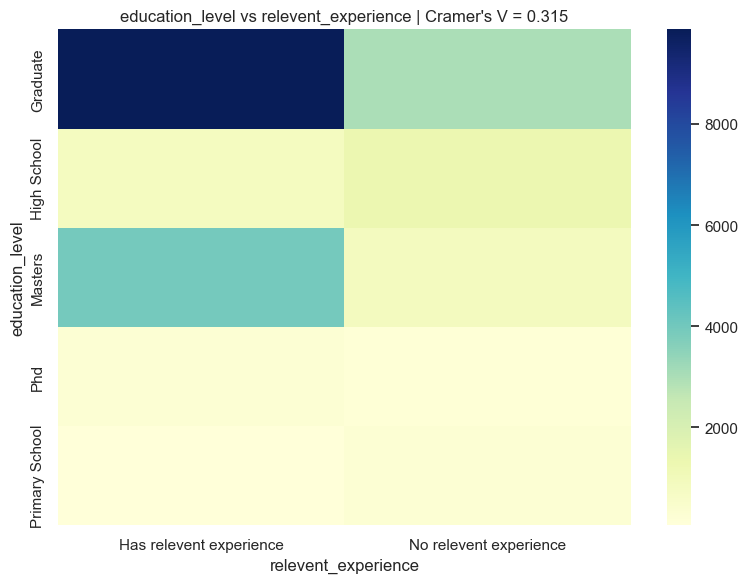

In [61]:
# Set the two feature names you want to inspect and rerun this cell.
FEATURE_X = "relevent_experience"
FEATURE_Y = "education_level"
MAX_CATEGORIES_TO_SHOW = 15

def plot_kind(column_name: str) -> str:
    inferred = profile.loc[profile["column"] == column_name, "inferred_type"].iloc[0]
    if inferred in {"numeric_continuous", "numeric_discrete"}:
        return "numeric"
    if inferred == "datetime":
        return "datetime"
    return "categorical"

def prepare_plot_series(column_name: str) -> pd.Series:
    kind = plot_kind(column_name)
    if kind == "datetime":
        return pd.to_datetime(df[column_name], errors="coerce", dayfirst=True)
    return df[column_name]

def cardinality_note(column_name: str) -> str:
    row = profile.loc[profile["column"] == column_name].iloc[0]
    if row["cardinality"] in {"high", "very high"} or "near-unique" in str(row["notes"]):
        return f"Warning: {column_name} is high-cardinality or near-unique, so apparent patterns may be unstable."
    return ""

if FEATURE_X not in df.columns or FEATURE_Y not in df.columns:
    raise KeyError(f"Choose feature names from the dataset columns. Available columns: {list(df.columns)}")

kind_x = plot_kind(FEATURE_X)
kind_y = plot_kind(FEATURE_Y)
series_x = prepare_plot_series(FEATURE_X)
series_y = prepare_plot_series(FEATURE_Y)
pair_df = pd.DataFrame({FEATURE_X: series_x, FEATURE_Y: series_y}).dropna()

print(f"Inspecting: {FEATURE_X} ({kind_x}) vs {FEATURE_Y} ({kind_y})")
print(f"Rows used: {len(pair_df):,}")
for note in [cardinality_note(FEATURE_X), cardinality_note(FEATURE_Y)]:
    if note:
        print(note)

if pair_df.empty:
    print("No overlapping non-null rows for this pair.")
elif {kind_x, kind_y} <= {"numeric", "datetime"}:
    x_vals = pair_df[FEATURE_X].map(pd.Timestamp.toordinal) if kind_x == "datetime" else pair_df[FEATURE_X]
    y_vals = pair_df[FEATURE_Y].map(pd.Timestamp.toordinal) if kind_y == "datetime" else pair_df[FEATURE_Y]
    plot_df = pd.DataFrame({FEATURE_X: x_vals, FEATURE_Y: y_vals}).dropna()
    spearman_value = plot_df[FEATURE_X].corr(plot_df[FEATURE_Y], method="spearman")
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_df, x=FEATURE_X, y=FEATURE_Y, alpha=0.35, s=35)
    sns.regplot(data=plot_df, x=FEATURE_X, y=FEATURE_Y, scatter=False, ci=None, color="#d1495b")
    plt.title(f"{FEATURE_X} vs {FEATURE_Y} | Spearman = {spearman_value:.3f}")
    if kind_x == "datetime":
        tick_positions = plot_df[FEATURE_X].sort_values().drop_duplicates()
        tick_positions = tick_positions.iloc[::max(1, len(tick_positions) // 8)]
        plt.xticks(tick_positions, [pd.Timestamp.fromordinal(int(v)).strftime("%Y-%m-%d") for v in tick_positions], rotation=45, ha="right")
    if kind_y == "datetime":
        tick_positions = plot_df[FEATURE_Y].sort_values().drop_duplicates()
        tick_positions = tick_positions.iloc[::max(1, len(tick_positions) // 8)]
        plt.yticks(tick_positions, [pd.Timestamp.fromordinal(int(v)).strftime("%Y-%m-%d") for v in tick_positions])
    plt.tight_layout()
    plt.show()
elif "categorical" in {kind_x, kind_y} and ("numeric" in {kind_x, kind_y} or "datetime" in {kind_x, kind_y}):
    categorical_feature = FEATURE_X if kind_x == "categorical" else FEATURE_Y
    numeric_feature = FEATURE_Y if categorical_feature == FEATURE_X else FEATURE_X
    plot_df = pair_df[[categorical_feature, numeric_feature]].copy()
    counts = plot_df[categorical_feature].astype(str).value_counts()
    kept_levels = counts.head(MAX_CATEGORIES_TO_SHOW).index
    plot_df = plot_df[plot_df[categorical_feature].astype(str).isin(kept_levels)].copy()
    plot_df[categorical_feature] = pd.Categorical(plot_df[categorical_feature].astype(str), categories=kept_levels, ordered=True)
    assoc_value = correlation_ratio(plot_df[categorical_feature], plot_df[numeric_feature])
    plt.figure(figsize=(max(10, 0.7 * len(kept_levels) + 4), 6))
    sns.boxplot(data=plot_df, x=categorical_feature, y=numeric_feature, color="#9ec1a3", showfliers=False)
    sns.stripplot(data=plot_df, x=categorical_feature, y=numeric_feature, color="#1d3557", alpha=0.25, size=3)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{numeric_feature} by {categorical_feature} | Correlation ratio = {assoc_value:.3f}")
    plt.tight_layout()
    plt.show()
else:
    plot_df = pair_df[[FEATURE_X, FEATURE_Y]].astype(str)
    x_levels = plot_df[FEATURE_X].value_counts().head(MAX_CATEGORIES_TO_SHOW).index
    y_levels = plot_df[FEATURE_Y].value_counts().head(MAX_CATEGORIES_TO_SHOW).index
    plot_df = plot_df[plot_df[FEATURE_X].isin(x_levels) & plot_df[FEATURE_Y].isin(y_levels)]
    contingency = pd.crosstab(plot_df[FEATURE_Y], plot_df[FEATURE_X])
    assoc_value = cramers_v(plot_df[FEATURE_X], plot_df[FEATURE_Y])
    plt.figure(figsize=(max(8, 0.7 * contingency.shape[1] + 3), max(6, 0.45 * contingency.shape[0] + 3)))
    sns.heatmap(contingency, cmap="YlGnBu", annot=False)
    plt.title(f"{FEATURE_Y} vs {FEATURE_X} | Cramer's V = {assoc_value:.3f}")
    plt.xlabel(FEATURE_X)
    plt.ylabel(FEATURE_Y)
    plt.tight_layout()
    plt.show()
